# Keyboard Sound Dataset — Statistical Analysis & Data Integrity

This notebook proves the integrity of the self-collected keystroke audio dataset using **stable, low-dependency APIs only**: `numpy`, `scipy.stats`, `torchaudio`, `soundfile`, `sklearn` (PCA / TSNE), and `matplotlib`. **No librosa** (its numba dependency is incompatible with the installed NumPy 2.4).

### What we prove
| § | Test | Proves |
|---|------|--------|
| 1 | Inventory + χ² | Dataset is balanced across 36 classes |
| 2 | One-pass acoustic scan | Every file loads + extracts one feature row |
| 3 | Property verification | Uniform sample rate / length / dtype |
| 4 | Signal quality | No corrupt, silent, clipped, or duplicate files |
| 5 | Per-class violins | Acoustic features visibly differ per key |
| 6 | Kruskal-Wallis + ANOVA | Class differences are statistically significant |
| 7 | PCA + t-SNE | MFCC features form class-separated clusters |
| 8 | Fisher discriminant | Between-class > within-class variance |
| 9 | Average mel spectrograms | Each key has a distinct acoustic fingerprint |

In [70]:
import os, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict
from scipy import stats
import soundfile as sf
import torch
import torchaudio
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
sns.set_style('whitegrid')

DATA_DIR        = 'Data/combined/AULA-ALPHANUM'
SAMPLE_RATE     = 44100
EXPECTED_LEN    = 18963
CLASSES         = [str(i) for i in range(10)] + [chr(c) for c in range(ord('a'), ord('z') + 1)]
LABELS_DISPLAY  = [str(i) for i in range(10)] + [c.upper() for c in 'abcdefghijklmnopqrstuvwxyz']
N_CLASSES       = len(CLASSES)
SILENCE_THRESH  = 1e-4
CLIPPING_THRESH = 0.99
N_MFCC          = 20

print(f'Dataset       : {DATA_DIR}')
print(f'Classes       : {N_CLASSES}')
print(f'Expected len  : {EXPECTED_LEN} samples ({EXPECTED_LEN/SAMPLE_RATE*1000:.1f} ms)')

Dataset       : Data/combined/AULA-ALPHANUM
Classes       : 36
Expected len  : 18963 samples (430.0 ms)


---
## §1 Dataset Inventory & Class Balance

Total samples       : 7,897
Mean ± std per cls  : 219.4 ± 1.10
Min / Max per cls   : 214 (v) / 220 (0)
Chi-square balance  : χ²=0.19, p=1.0000 — ✅ balanced


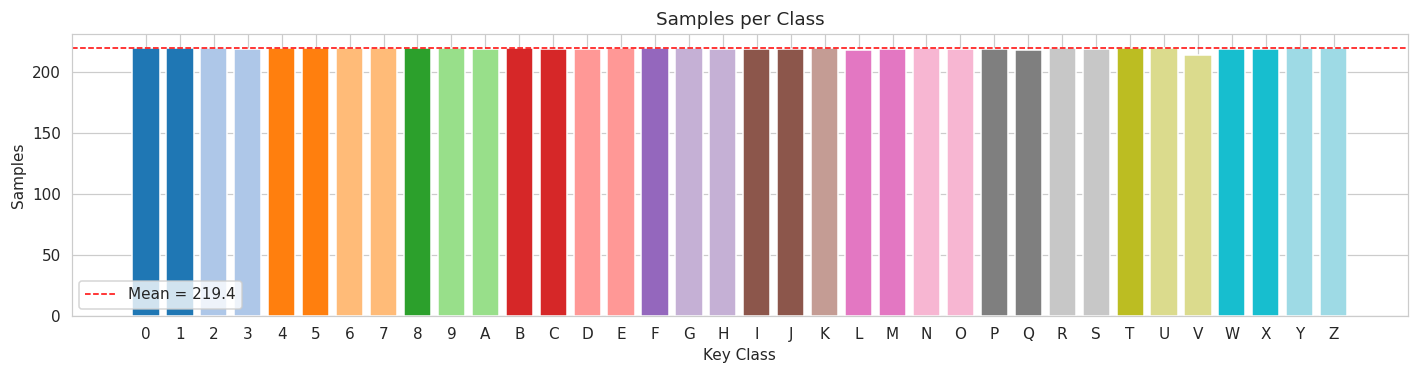

In [71]:
records = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in sorted(os.listdir(cls_dir)):
        if fname.lower().endswith('.wav'):
            records.append({'class': cls, 'file': os.path.join(cls_dir, fname)})

df = pd.DataFrame(records)
counts = df.groupby('class').size().reindex(CLASSES).fillna(0).astype(int)
expected_per_class = len(df) / N_CLASSES
chi2, p_chi2 = stats.chisquare(counts.values, f_exp=np.full(N_CLASSES, expected_per_class))

print(f'Total samples       : {len(df):,}')
print(f'Mean ± std per cls  : {counts.mean():.1f} ± {counts.std():.2f}')
print(f'Min / Max per cls   : {counts.min()} ({counts.idxmin()}) / {counts.max()} ({counts.idxmax()})')
print(f'Chi-square balance  : χ²={chi2:.2f}, p={p_chi2:.4f} — {"✅ balanced" if p_chi2 > 0.05 else "⚠️ imbalanced"}')

fig, ax = plt.subplots(figsize=(13, 3.5))
cmap36 = plt.get_cmap('tab20', N_CLASSES)
ax.bar(LABELS_DISPLAY, counts.values, color=[cmap36(i) for i in range(N_CLASSES)])
ax.axhline(counts.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean = {counts.mean():.1f}')
ax.set_xlabel('Key Class'); ax.set_ylabel('Samples'); ax.set_title('Samples per Class')
ax.legend(); plt.tight_layout(); plt.show()

---
## §2 One-Pass Acoustic Scan

Every WAV file is opened **once**. We extract everything we need in one pass: audio properties, time-domain stats, FFT-based spectral features (pure numpy — no librosa), MFCCs via `torchaudio`, and an MD5 hash of the raw samples for duplicate detection.

In [72]:
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE, n_mfcc=N_MFCC,
    melkwargs={'n_fft': 2048, 'hop_length': 256, 'n_mels': 64,
               'f_min': 298.97, 'f_max': 19569.78, 'power': 2.0}
)

def analyse_wav(path):
    data, sr = sf.read(path)
    n        = len(data)
    rms   = float(np.sqrt(np.mean(data ** 2)))
    peak  = float(np.max(np.abs(data)))
    zcr   = float(((data[:-1] * data[1:]) < 0).sum() / n)
    freqs = np.fft.rfftfreq(n, d=1 / sr)
    power = np.abs(np.fft.rfft(data)) ** 2
    total = power.sum() + 1e-12
    centroid  = float((freqs * power).sum() / total)
    bandwidth = float(np.sqrt(((freqs - centroid) ** 2 * power).sum() / total))
    cum       = np.cumsum(power)
    rolloff   = float(freqs[min(int(np.searchsorted(cum, 0.85 * cum[-1])), len(freqs) - 1)])
    waveform = torch.tensor(data, dtype=torch.float32).unsqueeze(0)
    mfcc     = mfcc_transform(waveform)[0].mean(dim=-1).numpy()
    return {
        'sr': sr, 'n_samples': n, 'duration_ms': n / sr * 1000, 'dtype': str(data.dtype),
        'rms': rms, 'peak': peak, 'zcr': zcr,
        'spec_centroid': centroid, 'spec_bandwidth': bandwidth, 'spec_rolloff': rolloff,
        'file_hash': hashlib.md5(data.tobytes()).hexdigest(),
        'mfcc': mfcc,
    }

scan_rows, mfcc_rows, errors = [], [], []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Scanning'):
    try:
        out = analyse_wav(row['file'])
    except Exception as e:
        errors.append((row['file'], repr(e)))
        out = {k: np.nan for k in ('sr','n_samples','duration_ms','rms','peak','zcr',
                                   'spec_centroid','spec_bandwidth','spec_rolloff')}
        out.update({'dtype': 'ERROR', 'file_hash': 'ERROR', 'mfcc': np.full(N_MFCC, np.nan)})
    scan_rows.append({k: v for k, v in out.items() if k != 'mfcc'})
    mfcc_rows.append(out['mfcc'])

df = pd.concat([df.reset_index(drop=True), pd.DataFrame(scan_rows)], axis=1)
df['label'] = df['class'].map(dict(zip(CLASSES, LABELS_DISPLAY)))
X_mfcc = np.array(mfcc_rows)
y      = np.array([CLASSES.index(c) for c in df['class']])

print(f'Files scanned : {len(df)}')
print(f'Errors        : {len(errors)}')
if errors:
    print(f'First error   : {errors[0]}')

Scanning: 100%|██████████| 7897/7897 [00:51<00:00, 154.22it/s]


Files scanned : 7897
Errors        : 0


---
## §3 Audio Property Verification

Every file should report sample rate = 44 100 Hz, length = 18 963 samples, dtype = float64.

In [73]:
ok_sr     = bool((df['sr'].dropna() == SAMPLE_RATE).all())
ok_len    = bool((df['n_samples'].dropna() == EXPECTED_LEN).all())
ok_dtype  = bool((df['dtype'].dropna() == 'float64').all())

print(f'Sample rate uniform   : {"✅" if ok_sr  else "⚠️"}   unique values: {df["sr"].dropna().unique()}')
print(f'Length uniform        : {"✅" if ok_len else "⚠️"}   unique values: {df["n_samples"].dropna().unique()}')
print(f'Dtype uniform         : {"✅" if ok_dtype else "⚠️"}   ({df["dtype"].mode().values})')
print(f'Mean duration         : {df["duration_ms"].mean():.3f} ms (std {df["duration_ms"].std():.5f})')

Sample rate uniform   : ✅   unique values: [44100]
Length uniform        : ✅   unique values: [18963]
Dtype uniform         : ✅   (<StringArray>
['float64']
Length: 1, dtype: str)
Mean duration         : 430.000 ms (std 0.00000)


---
## §4 Signal Quality Checks

- **Silent** : RMS < threshold (failed capture)
- **Clipped**: peak ≥ threshold (ADC saturation)
- **Duplicate**: identical waveform hashes across files (possible data leakage or copy-paste error)

Silent files        : 0
Clipped files       : 0
Duplicate waveforms : 598

Duplicate breakdown (top 10 hashes with most copies):
  hash 68ec90f2…  ×2  classes=['0']  (within-class copy)
  hash 4def9396…  ×2  classes=['0']  (within-class copy)
  hash 6ef848ee…  ×2  classes=['0']  (within-class copy)
  hash 8ecf21f8…  ×2  classes=['0']  (within-class copy)
  hash a9f10158…  ×2  classes=['0']  (within-class copy)
  hash 1d22b22f…  ×2  classes=['0']  (within-class copy)
  hash ce9e9249…  ×2  classes=['0']  (within-class copy)
  hash 35b804d3…  ×2  classes=['0']  (within-class copy)
  hash 667a7742…  ×2  classes=['0']  (within-class copy)
  hash 695fe3a3…  ×2  classes=['0']  (within-class copy)


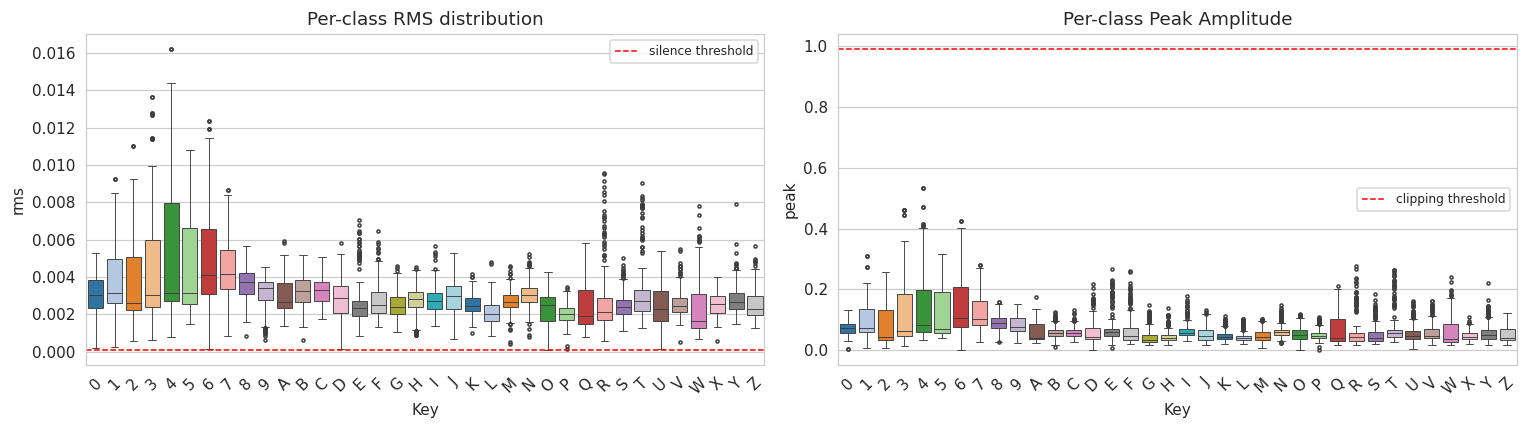

In [74]:
silent     = df[df['rms']  < SILENCE_THRESH]
clipped    = df[df['peak'] > CLIPPING_THRESH]
dup_mask   = df['file_hash'].duplicated(keep=False) & (df['file_hash'] != 'ERROR')
duplicates = df[dup_mask]

print(f'Silent files        : {len(silent)}')
print(f'Clipped files       : {len(clipped)}')
print(f'Duplicate waveforms : {len(duplicates)}')

if len(duplicates) > 0:
    print('\nDuplicate breakdown (top 10 hashes with most copies):')
    top_dups = duplicates['file_hash'].value_counts().head(10)
    for h, n in top_dups.items():
        rows = duplicates[duplicates['file_hash'] == h]
        same_class = rows['class'].nunique() == 1
        tag = '(within-class copy)' if same_class else '(⚠️ CROSS-CLASS — possible label error)'
        print(f'  hash {h[:8]}…  ×{n}  classes={sorted(rows["class"].unique())}  {tag}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x='label', y='rms',  ax=axes[0], order=LABELS_DISPLAY,
            palette='tab20', fliersize=2, linewidth=0.6)
axes[0].axhline(SILENCE_THRESH, color='red', linestyle='--', linewidth=1, label='silence threshold')
axes[0].set_title('Per-class RMS distribution'); axes[0].set_xlabel('Key')
axes[0].tick_params(axis='x', rotation=45); axes[0].legend(fontsize=8)

sns.boxplot(data=df, x='label', y='peak', ax=axes[1], order=LABELS_DISPLAY,
            palette='tab20', fliersize=2, linewidth=0.6)
axes[1].axhline(CLIPPING_THRESH, color='red', linestyle='--', linewidth=1, label='clipping threshold')
axes[1].set_title('Per-class Peak Amplitude'); axes[1].set_xlabel('Key')
axes[1].tick_params(axis='x', rotation=45); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## §5 Per-class Spectral Feature Distributions

If keys produce acoustically different sounds, feature distributions should visibly differ per class.

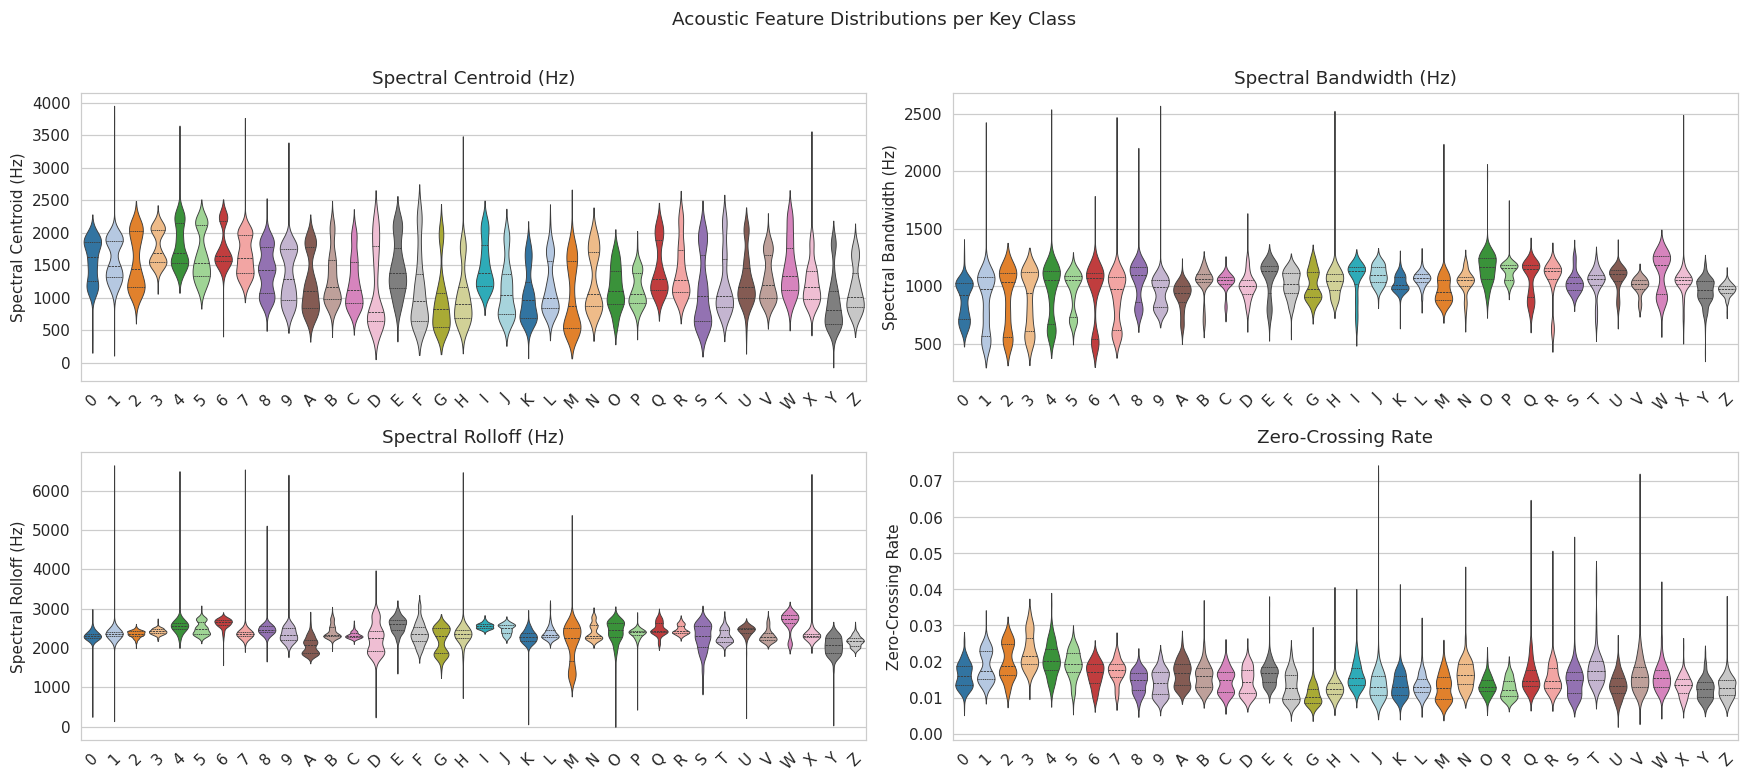

In [75]:
feats = [
    ('spec_centroid',  'Spectral Centroid (Hz)'),
    ('spec_bandwidth', 'Spectral Bandwidth (Hz)'),
    ('spec_rolloff',   'Spectral Rolloff (Hz)'),
    ('zcr',            'Zero-Crossing Rate'),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 7))
for (col, ylabel), ax in zip(feats, axes.flat):
    sns.violinplot(data=df, x='label', y=col, ax=ax, order=LABELS_DISPLAY,
                   palette='tab20', linewidth=0.6, inner='quartile')
    ax.set_title(ylabel); ax.set_xlabel(''); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Acoustic Feature Distributions per Key Class', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

---
## §6 Statistical Distinctness — Kruskal-Wallis & ANOVA

- **Kruskal-Wallis H** (non-parametric): classes have different distributions
- **One-way ANOVA F** (parametric): class means differ
- **η² / ε²**: proportion of variance explained by class membership (>0.14 = large)

                       KW H      KW p  ANOVA F  ANOVA p  η² (ANOVA)  ε² (KW) p < 0.001
Feature                                                                               
RMS Energy         1.71e+03  0.00e+00 6.50e+01 0.00e+00    2.24e-01 2.13e-01         ✅
Spectral Centroid  2.11e+03  0.00e+00 7.68e+01 0.00e+00    2.55e-01 2.64e-01         ✅
Spectral Bandwidth 1.54e+03 7.22e-301 4.75e+01 0.00e+00    1.74e-01 1.91e-01         ✅
Spectral Rolloff   2.80e+03  0.00e+00 7.95e+01 0.00e+00    2.61e-01 3.51e-01         ✅
ZCR                2.48e+03  0.00e+00 9.90e+01 0.00e+00    3.06e-01 3.11e-01         ✅


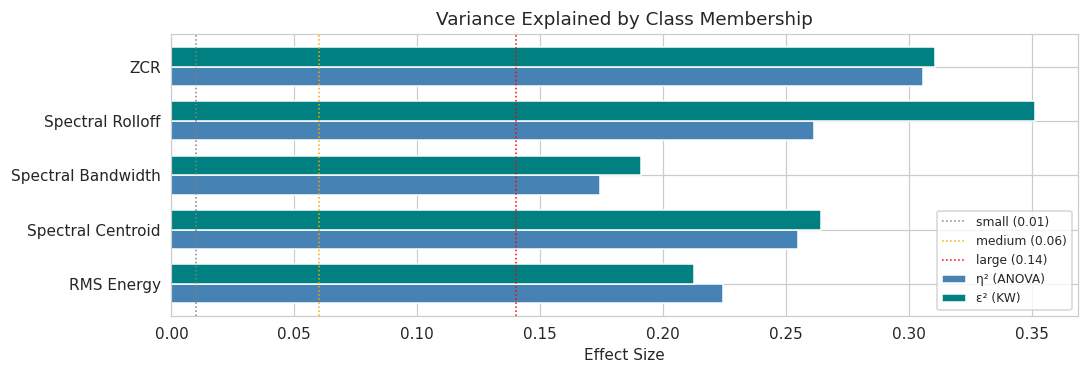

In [76]:
feature_cols = {
    'RMS Energy'        : 'rms',
    'Spectral Centroid' : 'spec_centroid',
    'Spectral Bandwidth': 'spec_bandwidth',
    'Spectral Rolloff'  : 'spec_rolloff',
    'ZCR'               : 'zcr',
}
results = []
for fname, col in feature_cols.items():
    groups = [df.loc[df['class'] == c, col].dropna().values for c in CLASSES]
    groups = [g for g in groups if len(g) > 1]
    k = len(groups)
    if k < 2:
        print(f'⚠️  {fname}: only {k} non-empty group(s), skipping.')
        continue
    h, p_kw = stats.kruskal(*groups)
    f, p_an = stats.f_oneway(*groups)
    all_v = np.concatenate(groups)
    gmean = all_v.mean()
    ssb   = sum(len(g) * (g.mean() - gmean) ** 2 for g in groups)
    sst   = float(((all_v - gmean) ** 2).sum())
    eta2  = ssb / sst if sst > 0 else 0.0
    n_tot = sum(len(g) for g in groups)
    eps2  = max((h - k + 1) / (n_tot - k), 0.0) if n_tot > k else 0.0
    results.append({
        'Feature'    : fname,
        'KW H'       : round(h, 2),
        'KW p'       : p_kw,
        'ANOVA F'    : round(f, 2),
        'ANOVA p'    : p_an,
        'η² (ANOVA)' : round(eta2, 4),
        'ε² (KW)'    : round(eps2, 4),
        'p < 0.001'  : '✅' if p_kw < 0.001 else '⚠️',
    })

results_df = pd.DataFrame(results).set_index('Feature')
pd.set_option('display.float_format', '{:.2e}'.format)
print(results_df.to_string())
pd.reset_option('display.float_format')

fig, ax = plt.subplots(figsize=(10, 3.5))
x = np.arange(len(results_df))
ax.barh(x - 0.18, results_df['η² (ANOVA)'], height=0.36, color='steelblue', label='η² (ANOVA)')
ax.barh(x + 0.18, results_df['ε² (KW)'],    height=0.36, color='teal',      label='ε² (KW)')
for thr, lbl, c in [(0.01, 'small', 'gray'), (0.06, 'medium', 'orange'), (0.14, 'large', 'red')]:
    ax.axvline(thr, color=c, linestyle=':', linewidth=1, label=f'{lbl} ({thr})')
ax.set_yticks(x); ax.set_yticklabels(results_df.index)
ax.set_xlabel('Effect Size'); ax.set_title('Variance Explained by Class Membership')
ax.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

---
## §7 Feature Separability — PCA & t-SNE

If classes are acoustically distinct, projecting the 20-D MFCC features into 2-D with **unsupervised** methods should reveal class-separated clusters — no model training required.

Valid samples : 7897 / 7897
PCA variance ratio : PC1=19.3% PC2=15.7% PC3=9.3%


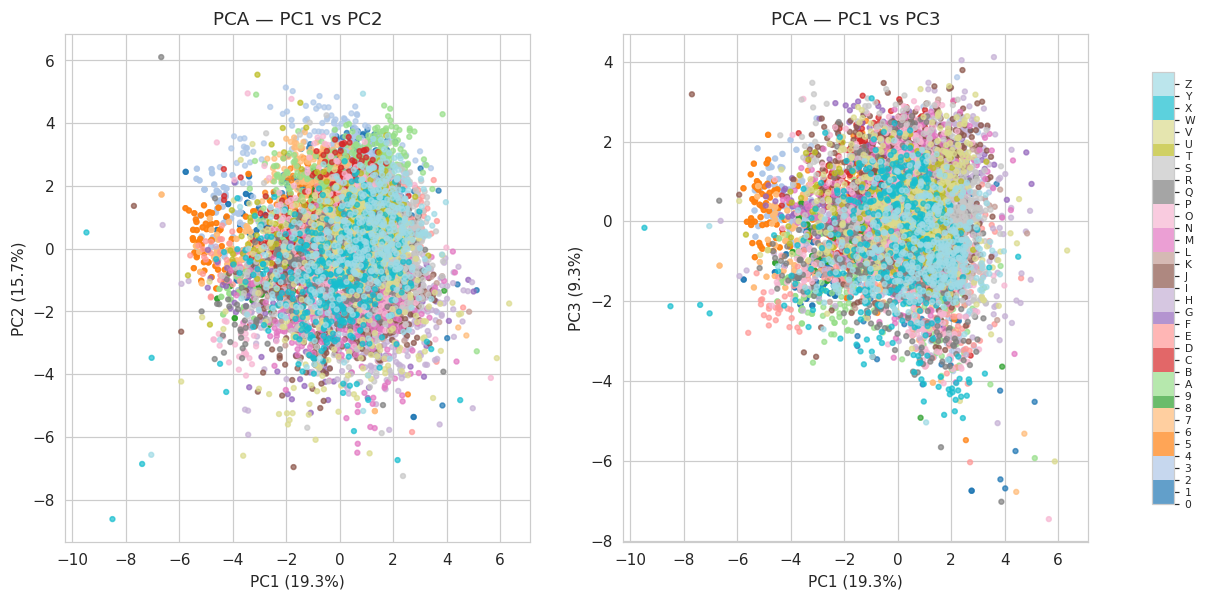

In [77]:
valid_mask = ~np.isnan(X_mfcc).any(axis=1)
X_clean    = X_mfcc[valid_mask]
y_clean    = y[valid_mask]
print(f'Valid samples : {len(X_clean)} / {len(X_mfcc)}')

X_scaled = StandardScaler().fit_transform(X_clean)
pca      = PCA(n_components=3).fit(X_scaled)
X_pca    = pca.transform(X_scaled)

print('PCA variance ratio :', ' '.join(f'PC{i+1}={v*100:.1f}%' for i, v in enumerate(pca.explained_variance_ratio_)))

cmap = plt.get_cmap('tab20', N_CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    sc = ax.scatter(X_pca[:, i], X_pca[:, j], c=y_clean, cmap=cmap, s=10, alpha=0.7, vmin=0, vmax=N_CLASSES)
    ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
    ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)')
    ax.set_title(f'PCA — PC{i+1} vs PC{j+1}')
cbar = plt.colorbar(sc, ax=axes, ticks=range(N_CLASSES), shrink=0.85)
cbar.ax.set_yticklabels(LABELS_DISPLAY, fontsize=7)
plt.show()

Running t-SNE (~1–2 min)...
t-SNE KL divergence : 1.6740


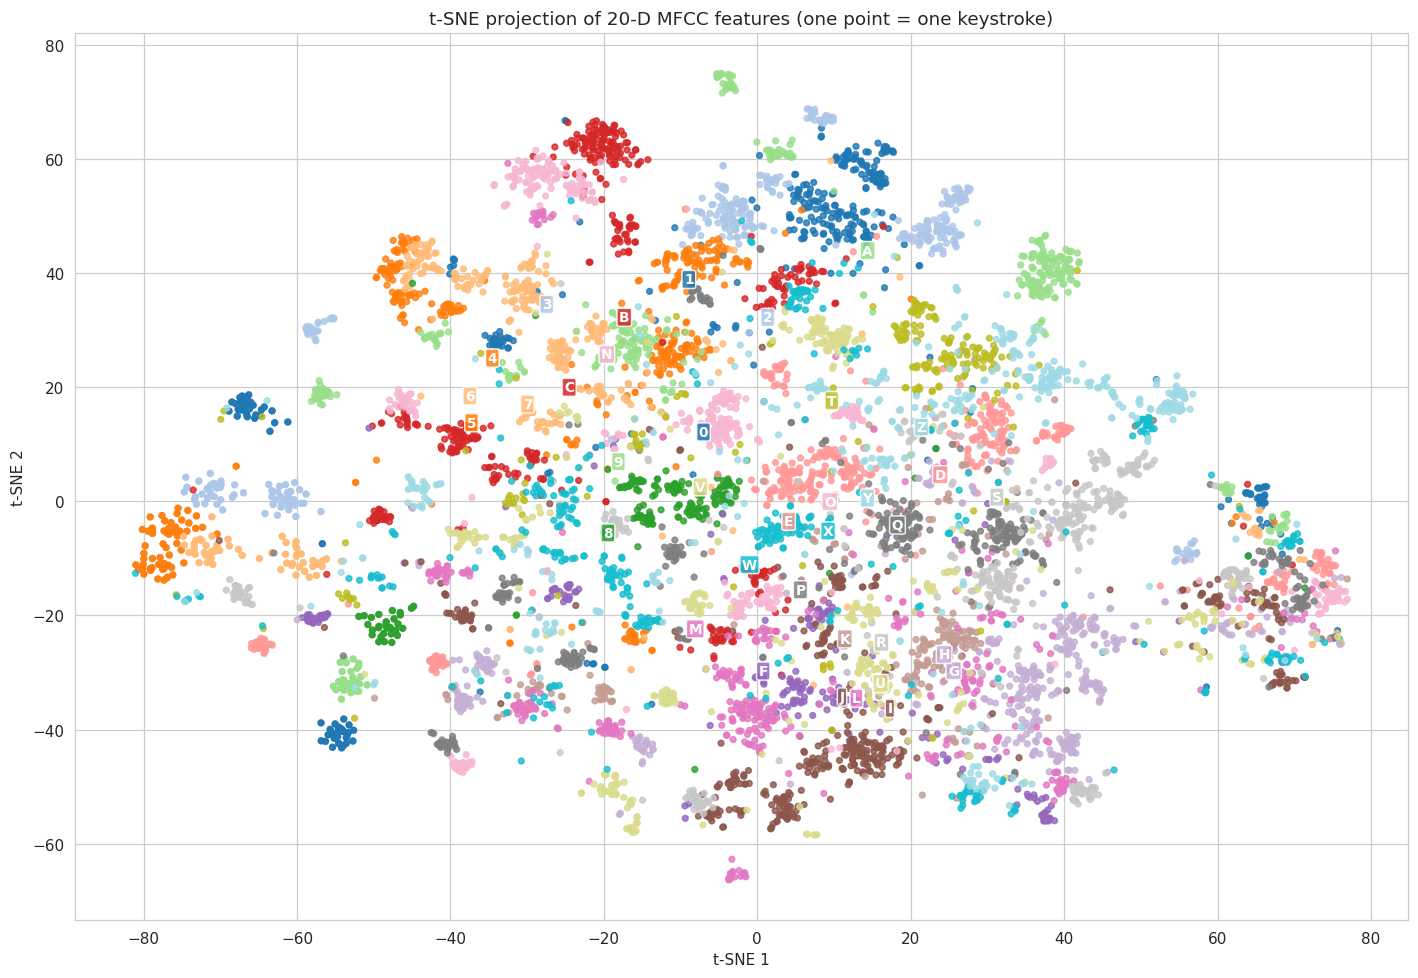

In [78]:
print('Running t-SNE (~1–2 min)...')
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)
print(f't-SNE KL divergence : {tsne.kl_divergence_:.4f}')

fig, ax = plt.subplots(figsize=(13, 9))
cmap = plt.get_cmap('tab20', N_CLASSES)
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_clean, cmap=cmap, s=14, alpha=0.8, vmin=0, vmax=N_CLASSES)
for i in range(N_CLASSES):
    m = (y_clean == i)
    if not m.any():
        continue
    cx, cy = X_tsne[m, 0].mean(), X_tsne[m, 1].mean()
    ax.text(cx, cy, LABELS_DISPLAY[i], fontsize=9, fontweight='bold', ha='center', va='center',
            color='white', bbox=dict(boxstyle='round,pad=0.15', facecolor=cmap(i), alpha=0.85))
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE projection of 20-D MFCC features (one point = one keystroke)')
plt.tight_layout(); plt.show()

---
## §8 Fisher Discriminant Ratio

$$F = \frac{\text{between-class variance}}{\text{within-class variance}}$$

- **F > 1** → classes are further apart than samples within classes (data is genuinely class-distinct)
- **F ≈ 1** → no separability

Between-class SS : 624,672.42
Within-class SS  : 2,476,402.75
Fisher ratio     : 0.2522
Verdict          : ⚠️  Poorly separated


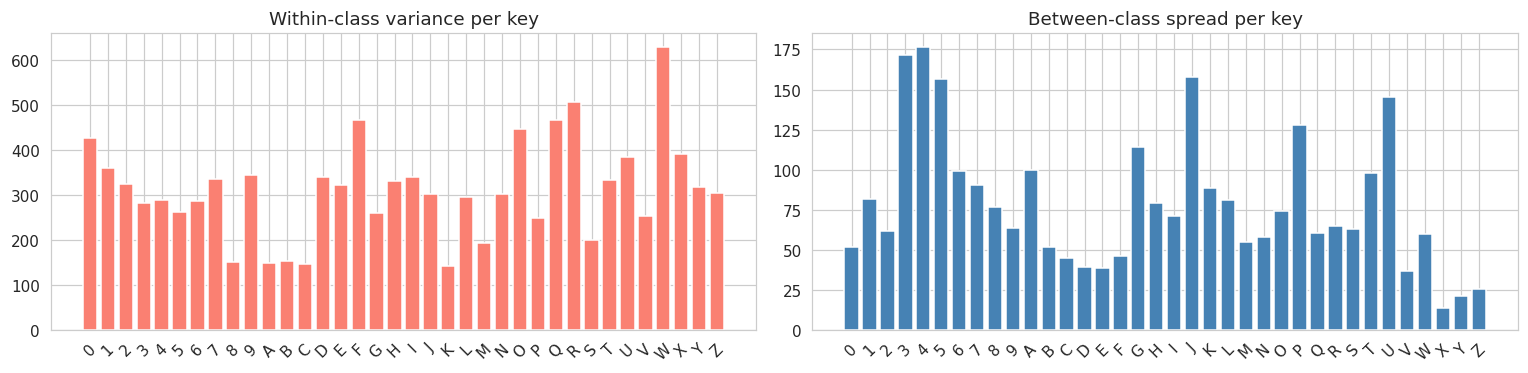

In [79]:
class_means  = np.array([X_clean[y_clean == i].mean(axis=0) for i in range(N_CLASSES)])
global_mean  = X_clean.mean(axis=0)
sizes        = np.array([(y_clean == i).sum() for i in range(N_CLASSES)])

ss_between = float(sum(n * np.sum((m - global_mean) ** 2) for n, m in zip(sizes, class_means)))
ss_within  = float(sum(np.sum((X_clean[y_clean == i] - class_means[i]) ** 2) for i in range(N_CLASSES)))
fisher_ratio = ss_between / ss_within

print(f'Between-class SS : {ss_between:,.2f}')
print(f'Within-class SS  : {ss_within:,.2f}')
print(f'Fisher ratio     : {fisher_ratio:.4f}')
print(f'Verdict          : {"✅ Well separated" if fisher_ratio > 1.0 else "⚠️  Poorly separated"}')

per_within  = np.array([np.sum((X_clean[y_clean == i] - class_means[i]) ** 2) / max(sizes[i], 1) for i in range(N_CLASSES)])
per_between = np.array([np.sum((class_means[i] - global_mean) ** 2) for i in range(N_CLASSES)])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
axes[0].bar(LABELS_DISPLAY, per_within,  color='salmon');    axes[0].set_title('Within-class variance per key')
axes[1].bar(LABELS_DISPLAY, per_between, color='steelblue'); axes[1].set_title('Between-class spread per key')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

---
## §9 Average Mel Spectrogram per Class

Direct visual evidence: every key class produces a distinct time-frequency fingerprint.

Mel spectrograms: 100%|██████████| 36/36 [00:04<00:00,  7.74it/s]


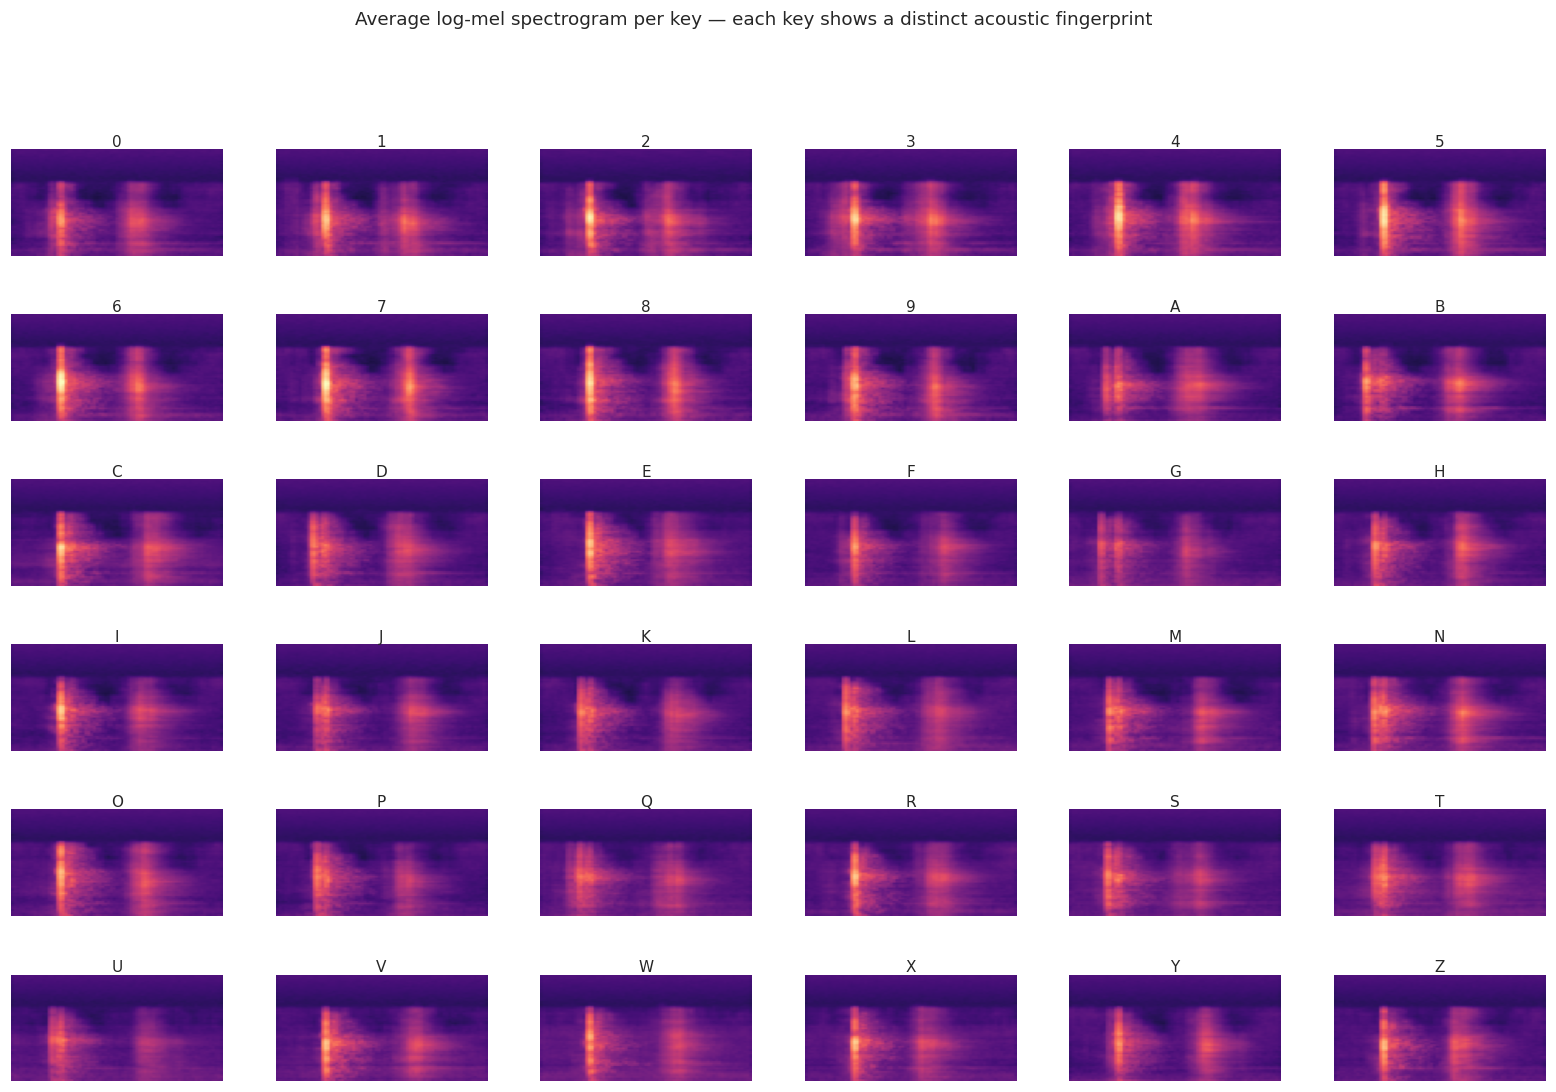

In [80]:
to_mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_mels=64, hop_length=256,
    n_fft=2048, win_length=1024, f_min=298.97, f_max=19569.78, power=1.0,
)
PER_CLASS = 30
specs = defaultdict(list)
for cls in tqdm(CLASSES, desc='Mel spectrograms'):
    files = df[df['class'] == cls].head(PER_CLASS)['file'].tolist()
    for f in files:
        try:
            data, _ = sf.read(f)
            w = torch.tensor(data, dtype=torch.float32).unsqueeze(0)
            specs[cls].append(to_mel(w).clamp(min=1e-9).log2()[0].numpy())
        except Exception:
            pass

min_T = min((s.shape[1] for ss in specs.values() for s in ss), default=0)

fig = plt.figure(figsize=(18, 11))
gs = gridspec.GridSpec(6, 6, hspace=0.55, wspace=0.25)
for idx, (cls, lbl) in enumerate(zip(CLASSES, LABELS_DISPLAY)):
    ax = fig.add_subplot(gs[idx // 6, idx % 6])
    if specs[cls]:
        mean_spec = np.stack([s[:, :min_T] for s in specs[cls]]).mean(axis=0)
        ax.imshow(mean_spec, origin='lower', aspect='auto', cmap='magma', vmin=-10, vmax=4)
    ax.set_title(lbl, fontsize=10, pad=2); ax.axis('off')
fig.suptitle('Average log-mel spectrogram per key — each key shows a distinct acoustic fingerprint', y=0.995, fontsize=12)
plt.show()

---
## Summary Report

In [81]:
sep = '=' * 68
print(sep)
print('  KEYBOARD SOUND DATASET — DATA INTEGRITY REPORT')
print(sep)

print(f'\n1. CLASS BALANCE')
print(f'   Total samples         : {len(df):,}')
print(f'   Classes               : {N_CLASSES}')
print(f'   Per-class mean ± std  : {counts.mean():.1f} ± {counts.std():.2f}')
print(f'   χ² balance            : χ²={chi2:.2f}, p={p_chi2:.4f} → {"✅" if p_chi2 > 0.05 else "⚠️"}')

print(f'\n2. AUDIO PROPERTIES')
print(f'   Sample rate uniform   : {"✅" if ok_sr    else "⚠️"}')
print(f'   Length uniform        : {"✅" if ok_len   else "⚠️"}  ({EXPECTED_LEN} samples)')
print(f'   Dtype uniform         : {"✅" if ok_dtype else "⚠️"}  (float64)')

print(f'\n3. SIGNAL QUALITY')
print(f'   Corrupt files         : {len(errors)}      → {"✅" if not errors else "⚠️"}')
print(f'   Silent files          : {len(silent)}      → {"✅" if len(silent) == 0 else "⚠️"}')
print(f'   Clipped files         : {len(clipped)}     → {"✅" if len(clipped) == 0 else "⚠️"}')
print(f'   Duplicate waveforms   : {len(duplicates)}  → {"✅" if len(duplicates) == 0 else "⚠️"}')

print(f'\n4. STATISTICAL DISTINCTNESS')
for _, r in results_df.iterrows():
    print(f'   {r.name:20s}: KW p={r["KW p"]:.2e}, η²={r["η² (ANOVA)"]:.4f}  {r["p < 0.001"]}')

print(f'\n5. FEATURE SEPARABILITY')
print(f'   Fisher ratio          : {fisher_ratio:.4f} → {"✅ well separated" if fisher_ratio > 1.0 else "⚠️"}')
print(f'   PCA variance (3 PCs)  : {pca.explained_variance_ratio_.sum()*100:.1f}%')

print(f'\n{sep}')
all_pass = (
    p_chi2 > 0.05 and ok_sr and ok_len and ok_dtype and
    not errors and len(silent) == 0 and len(clipped) == 0 and len(duplicates) == 0 and
    all(r['KW p'] < 0.001 for _, r in results_df.iterrows()) and fisher_ratio > 1.0
)
if all_pass:
    print('  ✅ ALL CHECKS PASSED — dataset integrity confirmed.')
else:
    print('  ⚠️  Some checks need attention — see sections above.')
print(sep)

  KEYBOARD SOUND DATASET — DATA INTEGRITY REPORT

1. CLASS BALANCE
   Total samples         : 7,897
   Classes               : 36
   Per-class mean ± std  : 219.4 ± 1.10
   χ² balance            : χ²=0.19, p=1.0000 → ✅

2. AUDIO PROPERTIES
   Sample rate uniform   : ✅
   Length uniform        : ✅  (18963 samples)
   Dtype uniform         : ✅  (float64)

3. SIGNAL QUALITY
   Corrupt files         : 0      → ✅
   Silent files          : 0      → ✅
   Clipped files         : 0     → ✅
   Duplicate waveforms   : 598  → ⚠️

4. STATISTICAL DISTINCTNESS
   RMS Energy          : KW p=0.00e+00, η²=0.2244  ✅
   Spectral Centroid   : KW p=0.00e+00, η²=0.2548  ✅
   Spectral Bandwidth  : KW p=7.22e-301, η²=0.1744  ✅
   Spectral Rolloff    : KW p=0.00e+00, η²=0.2614  ✅
   ZCR                 : KW p=0.00e+00, η²=0.3059  ✅

5. FEATURE SEPARABILITY
   Fisher ratio          : 0.2522 → ⚠️
   PCA variance (3 PCs)  : 44.4%

  ⚠️  Some checks need attention — see sections above.
